In [1]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

In [2]:
def u0_inviscid(x: float, uL: float, uR: float):
    return jnp.where(x==0, 0.5 * (uL + uR), jnp.where(x > 0, uR, uL))

def u0(x: float, uL: float, uR: float, nu: float):
    ans = 0.5 * (uL + uR)
    ans -= (uL-uR) * 0.5 * jnp.tanh(jnp.abs(uL-uR)*x/(4.*nu))
    return ans

def u(x: float, t: float, uL: float, uR: float, nu: float):
    speed = 0.5 * (uL + uR)
    return u0(x - speed * t, uL, uR, nu)

u0_x = jax.grad(u0, argnums=0)
u0_xx = jax.grad(u0_x, argnums=0)

def predict_u_eulerian(x: float, t: float, uL: float, uR: float, nu: float):
    return u0(x, uL, uR, nu) + t * (u0_xx(x, uL, uR, nu) * nu - u0(x, uL, uR, nu)*u0_x(x, uL, uR, nu))

def predict_u_lagrangian(x0: float, t: float, uL: float, uR: float, nu: float):
    x1 = x0 + t * u0(x0, uL, uR, nu)
    return x1, u0(x0, uL, uR, nu) + t * u0_xx(x0, uL, uR, nu) * nu

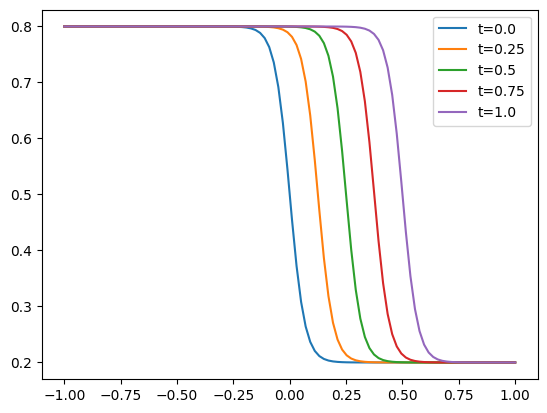

In [5]:
uL = 0.8
uR = 0.2
nu = 0.01

xlist = jnp.linspace(-1.0, 1.0, 100)

for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    plt.plot(xlist, jax.vmap(lambda x: u(x, t, uL, uR, nu))(xlist), label=f"t={t}")
plt.legend()
plt.show()


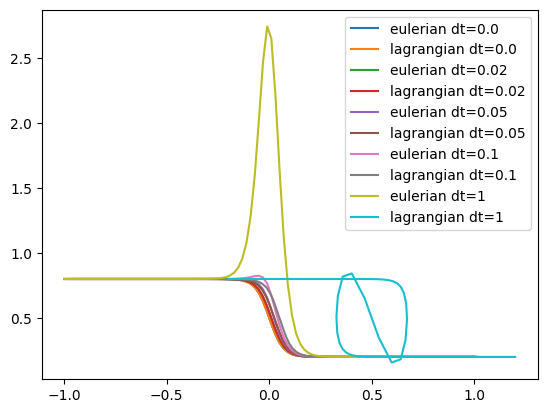

In [7]:
uL = 0.8
uR = 0.2
nu = 0.01

u0_x = jax.grad(u0, argnums=0)
u0_xx = jax.grad(u0_x, argnums=0)

u0_t_estimate = lambda x, uL, uR, nu: u0_xx(x, uL, uR, nu) * nu - u0(x, uL, uR, nu)*u0_x(x, uL, uR, nu)

xlist = jnp.linspace(-1.0, 1.0, 100)

u0_t_estimate_eval = jax.vmap(lambda x: u0_t_estimate(x, uL, uR, nu))(xlist)
u0_eval = jax.vmap(lambda x: u0(x, uL, uR, nu))(xlist)

for dt in [0.0, 0.02, 0.05, 0.1, 1]:
    u_predict_euler = jax.vmap(lambda x: predict_u_eulerian(x, dt, uL, uR, nu))(xlist)
    xlist_l, u_predict_lagrangian = jax.vmap(lambda x: predict_u_lagrangian(x, dt, uL, uR, nu))(xlist)
    plt.plot(xlist, u_predict_euler, label=f"eulerian dt={dt}")
    plt.plot(xlist_l, u_predict_lagrangian, label=f"lagrangian dt={dt}")
plt.legend()

In [8]:
x_lo, x_hi = -2.0, 2.0
xlist = jnp.linspace(-10.0, 10.0, 20001)

for dt in [0.02, 0.05, 0.1, 1.0]:
    u_pred_e = jax.vmap(lambda x: predict_u_eulerian(x, dt, uL, uR, nu))(xlist)
    u_true_e = jax.vmap(lambda x: u(x, dt, uL, uR, nu))(xlist)
    mask_e = (xlist >= x_lo) & (xlist <= x_hi)
    err_e = jnp.sqrt(jnp.trapezoid(jnp.where(mask_e, (u_pred_e - u_true_e) ** 2, 0.0), xlist))

    x1, u_pred_l = jax.vmap(lambda x: predict_u_lagrangian(x, dt, uL, uR, nu))(xlist)
    u_true_l = jax.vmap(lambda x: u(x, dt, uL, uR, nu))(x1)
    order = jnp.argsort(x1)
    x1_s = x1[order]
    diff_sq_s = ((u_pred_l - u_true_l) ** 2)[order]
    mask_l = (x1_s >= x_lo) & (x1_s <= x_hi)
    err_l = jnp.sqrt(jnp.trapezoid(jnp.where(mask_l, diff_sq_s, 0.0), x1_s))

    print(f"dt={dt:<6}  eulerian L2 err = {float(err_e):.6e}   lagrangian L2 err = {float(err_l):.6e}")

dt=0.02    eulerian L2 err = 8.983965e-04   lagrangian L2 err = 1.598168e-04
dt=0.05    eulerian L2 err = 5.563094e-03   lagrangian L2 err = 1.014839e-03
dt=0.1     eulerian L2 err = 2.154914e-02   lagrangian L2 err = 4.162614e-03
dt=1.0     eulerian L2 err = 6.526880e-01   lagrangian L2 err = 2.039396e-01


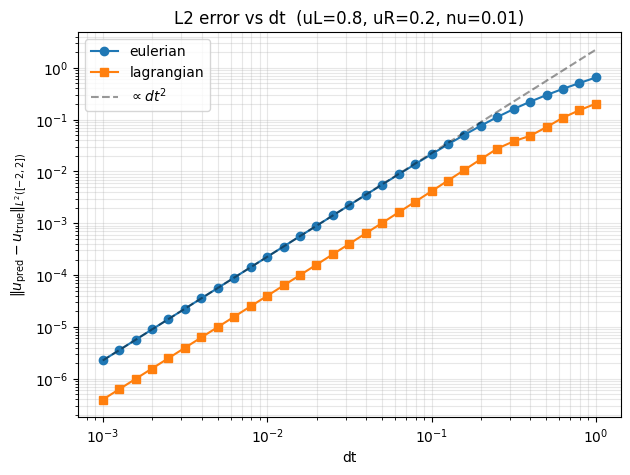

In [9]:
x_lo, x_hi = -2.0, 2.0
xlist = jnp.linspace(-10.0, 10.0, 20001)

def l2_errors(dt):
    u_pred_e = jax.vmap(lambda x: predict_u_eulerian(x, dt, uL, uR, nu))(xlist)
    u_true_e = jax.vmap(lambda x: u(x, dt, uL, uR, nu))(xlist)
    mask_e = (xlist >= x_lo) & (xlist <= x_hi)
    err_e = jnp.sqrt(jnp.trapezoid(jnp.where(mask_e, (u_pred_e - u_true_e) ** 2, 0.0), xlist))

    x1, u_pred_l = jax.vmap(lambda x: predict_u_lagrangian(x, dt, uL, uR, nu))(xlist)
    u_true_l = jax.vmap(lambda x: u(x, dt, uL, uR, nu))(x1)
    order = jnp.argsort(x1)
    x1_s = x1[order]
    diff_sq_s = ((u_pred_l - u_true_l) ** 2)[order]
    mask_l = (x1_s >= x_lo) & (x1_s <= x_hi)
    err_l = jnp.sqrt(jnp.trapezoid(jnp.where(mask_l, diff_sq_s, 0.0), x1_s))
    return err_e, err_l

dts = jnp.logspace(-3, 0, 31)
errs = jnp.array([l2_errors(float(dt)) for dt in dts])
err_e, err_l = errs[:, 0], errs[:, 1]

plt.figure(figsize=(7, 5))
plt.loglog(dts, err_e, "o-", label="eulerian")
plt.loglog(dts, err_l, "s-", label="lagrangian")
plt.loglog(dts, dts ** 2 * float(err_e[0]) / float(dts[0]) ** 2, "k--", alpha=0.4, label=r"$\propto dt^2$")
plt.xlabel("dt")
plt.ylabel(r"$\|u_\mathrm{pred}-u_\mathrm{true}\|_{L^2([-2,2])}$")
plt.title(f"L2 error vs dt  (uL={uL}, uR={uR}, nu={nu})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()